# 🎮 Análise Estatística de Dados de League of Legends Esports

## Projeto de Análise de Dados - Worlds 2024

**Objetivo:** Aplicar técnicas de análise estatística e de dados para explorar um dataset de jogadores profissionais de League of Legends, identificar padrões e tendências, e propor soluções práticas para problemas específicos.

**Dataset:** Estatísticas de jogadores profissionais do Mundial de League of Legends 2024

---

## 📚 1. Importação das Bibliotecas

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

import warnings
warnings.filterwarnings('ignore')

## 📂 2. Carregamento e Exploração Inicial dos Dados

In [188]:
df = pd.read_csv('player_statistics_cleaned_final.csv')

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"{df['PlayerName'].nunique()} jogadores únicos")
print(f"{df['TeamName'].nunique()} times únicos")
print(f"{df['Country'].nunique()} países representados")

display(df.head())

Dataset carregado com sucesso!
Dimensões: 81 linhas e 27 colunas
81 jogadores únicos
16 times únicos
16 países representados


,TeamName,PlayerName,Position,Games,Win rate,KDA,Avg kills,Avg deaths,Avg assists,CSPerMin,GoldPerMin,KP%,DamagePercent,DPM,VSPM,Avg WPM,Avg WCPM,Avg VWPM,GD@15,CSD@15,XPD@15,FB %,FB Victim,Penta Kills,Solo Kills,Country,FlashKeybind
0,Top Esports,369,Top,8,0.500,3.1,2.5,2.4,4.9,7.6,373,0.532,0.219,508,0.91,0.38,0.11,0.13,322,5,424,0.000,0.25,0,2,China,D
1,Dplus KIA,aiming,Adc,9,0.333,4.8,5.0,2.0,4.7,10.1,449,0.815,0.308,650,1.16,0.39,0.34,0.10,-112,1,97,0.333,0.00,0,2,South Korea,F
2,MAD Lions KOI,alvaro,Support,5,0.200,1.5,0.2,4.4,6.2,1.2,233,0.622,0.079,173,3.59,1.91,0.52,0.49,-3,2,-256,0.000,0.60,0,-,Spain,D
3,Team Liquid,apa,Mid,10,0.500,2.4,3.5,3.2,4.2,8.7,418,0.592,0.266,612,1.54,0.58,0.32,0.18,278,2,216,0.400,0.00,0,3,United States,D
4,PSG Talon,azhi,Top,5,0.200,2.3,2.2,3.0,4.8,7.5,357,0.542,0.208,523,1.12,0.43,0.23,0.18,-311,-10,-168,0.200,0.00,0,-,Taiwan,D


In [189]:
print("Informações do Dataset:")
print(df.info())
print("\n" + "="*50)

print("Valores Ausentes:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
if len(missing_values) > 0:
    display(missing_values)
else:
    print("Nenhum valor ausente detectado!")

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TeamName       81 non-null     object 
 1   PlayerName     81 non-null     object 
 2   Position       81 non-null     object 
 3   Games          81 non-null     int64  
 4   Win rate       81 non-null     float64
 5   KDA            81 non-null     float64
 6   Avg kills      81 non-null     float64
 7   Avg deaths     81 non-null     float64
 8   Avg assists    81 non-null     float64
 9   CSPerMin       81 non-null     float64
 10  GoldPerMin     81 non-null     int64  
 11  KP%            81 non-null     float64
 12  DamagePercent  81 non-null     float64
 13  DPM            81 non-null     int64  
 14  VSPM           81 non-null     float64
 15  Avg WPM        81 non-null     float64
 16  Avg WCPM       81 non-null     float64
 17  Avg VWPM       81 non-null     f

In [190]:
print("Estatísticas Descritivas das Principais Métricas:")
key_metrics = ['Win rate', 'KDA', 'Avg kills', 'Avg deaths', 'Avg assists', 
               'DamagePercent', 'GoldPerMin', 'KP%', 'CSPerMin']
display(df[key_metrics].describe().round(3))

Estatísticas Descritivas das Principais Métricas:


,Win rate,KDA,Avg kills,Avg deaths,Avg assists,DamagePercent,GoldPerMin,KP%,CSPerMin
count,81.000,81.000,81.000,81.000,81.000,81.000,81.000,81.000,81.000
mean,0.456,3.765,2.686,2.875,6.756,0.200,362.654,0.681,6.657
std,0.215,1.835,1.519,0.897,2.390,0.084,72.096,0.089,3.049
min,0.000,1.200,0.200,1.300,1.800,0.052,225.000,0.410,1.000
25%,0.333,2.400,1.200,2.400,4.900,0.135,320.000,0.623,5.700
50%,0.500,3.400,2.500,2.900,6.200,0.215,385.000,0.691,7.900
75%,0.615,4.400,3.900,3.300,8.300,0.275,416.000,0.751,8.900
max,0.875,9.300,5.600,5.600,12.400,0.337,486.000,0.849,10.500


## 3. Limpeza e Preparação dos Dados

In [220]:
def preprocess_data(df):
    data = df.copy()
    
    data['Solo Kills'] = data['Solo Kills'].replace('-', np.nan)
    
    numeric_columns = ['Games', 'Win rate', 'KDA', 'Avg kills', 'Avg deaths', 'Avg assists',
                      'CSPerMin', 'GoldPerMin', 'KP%', 'DamagePercent', 'DPM', 'VSPM',
                      'Avg WPM', 'Avg WCPM', 'Avg VWPM', 'GD@15', 'CSD@15', 'XPD@15',
                      'FB %', 'Penta Kills', 'Solo Kills']
    
    for col in numeric_columns:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
    
    print(f"• {len(numeric_columns)} colunas convertidas para tipo numérico")
    
    return data

data = preprocess_data(df)

print('\nValores Ausentes')
missing_after = data.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) > 0:
    display(missing_after)
    print(f"\nTotal de valores ausentes: {data.isnull().sum().sum()}")
else:
    print("✓ Todos os valores ausentes foram tratados")

print(f"\nRegistros completos: {data.dropna().shape[0]}/{data.shape[0]}")

• 21 colunas convertidas para tipo numérico

Valores Ausentes


Solo Kills    38
dtype: int64


Total de valores ausentes: 38

Registros completos: 43/81


In [192]:
print("Criando novas variáveis...")

data['Kill_Death_Ratio'] = data['Avg kills'] / data['Avg deaths'].replace(0, 0.1)
data['Efficiency_Score'] = (data['Avg kills'] + data['Avg assists']) / data['Avg deaths'].replace(0, 0.1)
data['Economic_Efficiency'] = data['GoldPerMin'] / data['CSPerMin'].replace(0, 1)

data['Early_Game_Advantage'] = (data['GD@15'] + data['CSD@15'] + data['XPD@15']) / 3

data['Team_Contribution'] = data['KP%'] * data['DamagePercent']
data['Vision_Control'] = (data['Avg WPM'] + data['Avg WCPM'] + data['Avg VWPM']) / 3

performance_metrics = ['KDA', 'Win rate', 'DamagePercent', 'KP%']
data['Performance_Score'] = data[performance_metrics].fillna(0).mean(axis=1)

data['Performance_Tier'] = pd.cut(data['Performance_Score'], 
                                 bins=[0, 0.3, 0.5, 0.7, 1.0], 
                                 labels=['Low', 'Medium', 'High', 'Elite'])

new_variables = ['Kill_Death_Ratio', 'Efficiency_Score', 'Economic_Efficiency', 
                'Early_Game_Advantage', 'Team_Contribution', 'Vision_Control', 
                'Performance_Score', 'Performance_Tier']

print(f"{len(new_variables)} novas variáveis criadas:")
for var in new_variables:
    print(f"   • {var}")

Criando novas variáveis...
8 novas variáveis criadas:
   • Kill_Death_Ratio
   • Efficiency_Score
   • Economic_Efficiency
   • Early_Game_Advantage
   • Team_Contribution
   • Vision_Control
   • Performance_Score
   • Performance_Tier


## 4. Análise Exploratória de Dados (EDA)

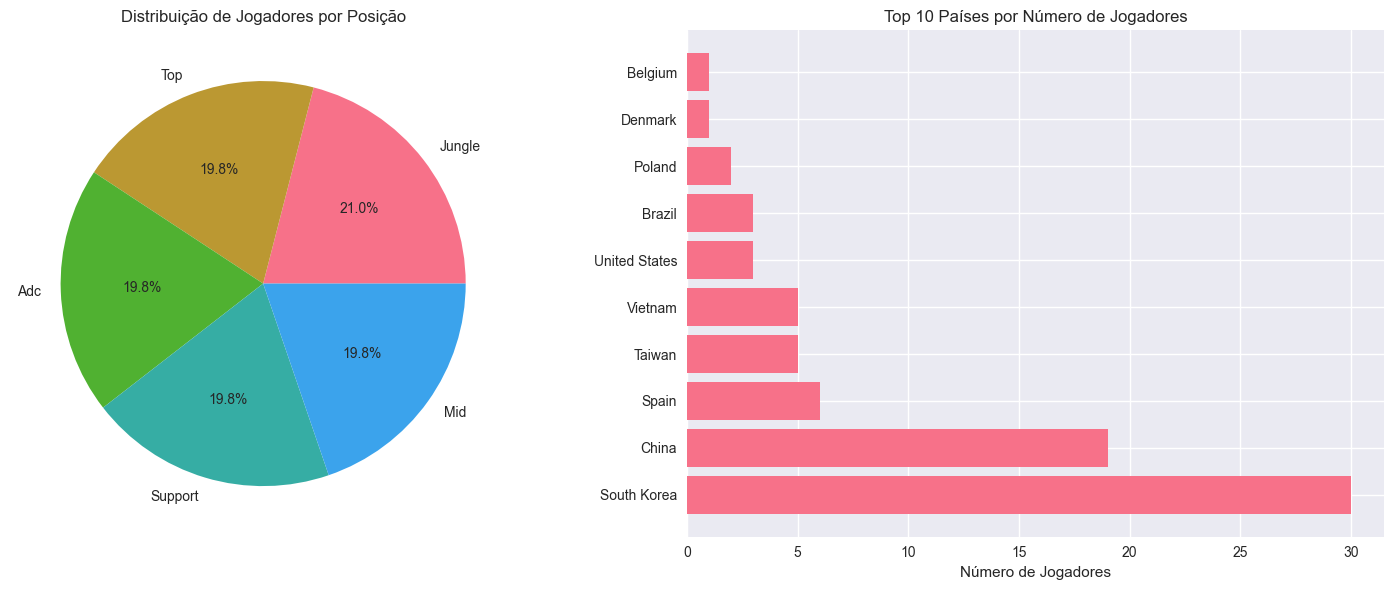

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

position_counts = data['Position'].value_counts()
axes[0].pie(position_counts.values, labels=position_counts.index, autopct='%1.1f%%')
axes[0].set_title('Distribuição de Jogadores por Posição')

top_countries = data['Country'].value_counts().head(10)
axes[1].barh(range(len(top_countries)), top_countries.values)
axes[1].set_yticks(range(len(top_countries)))
axes[1].set_yticklabels(top_countries.index)
axes[1].set_title('Top 10 Países por Número de Jogadores')
axes[1].set_xlabel('Número de Jogadores')

plt.tight_layout()
plt.show()

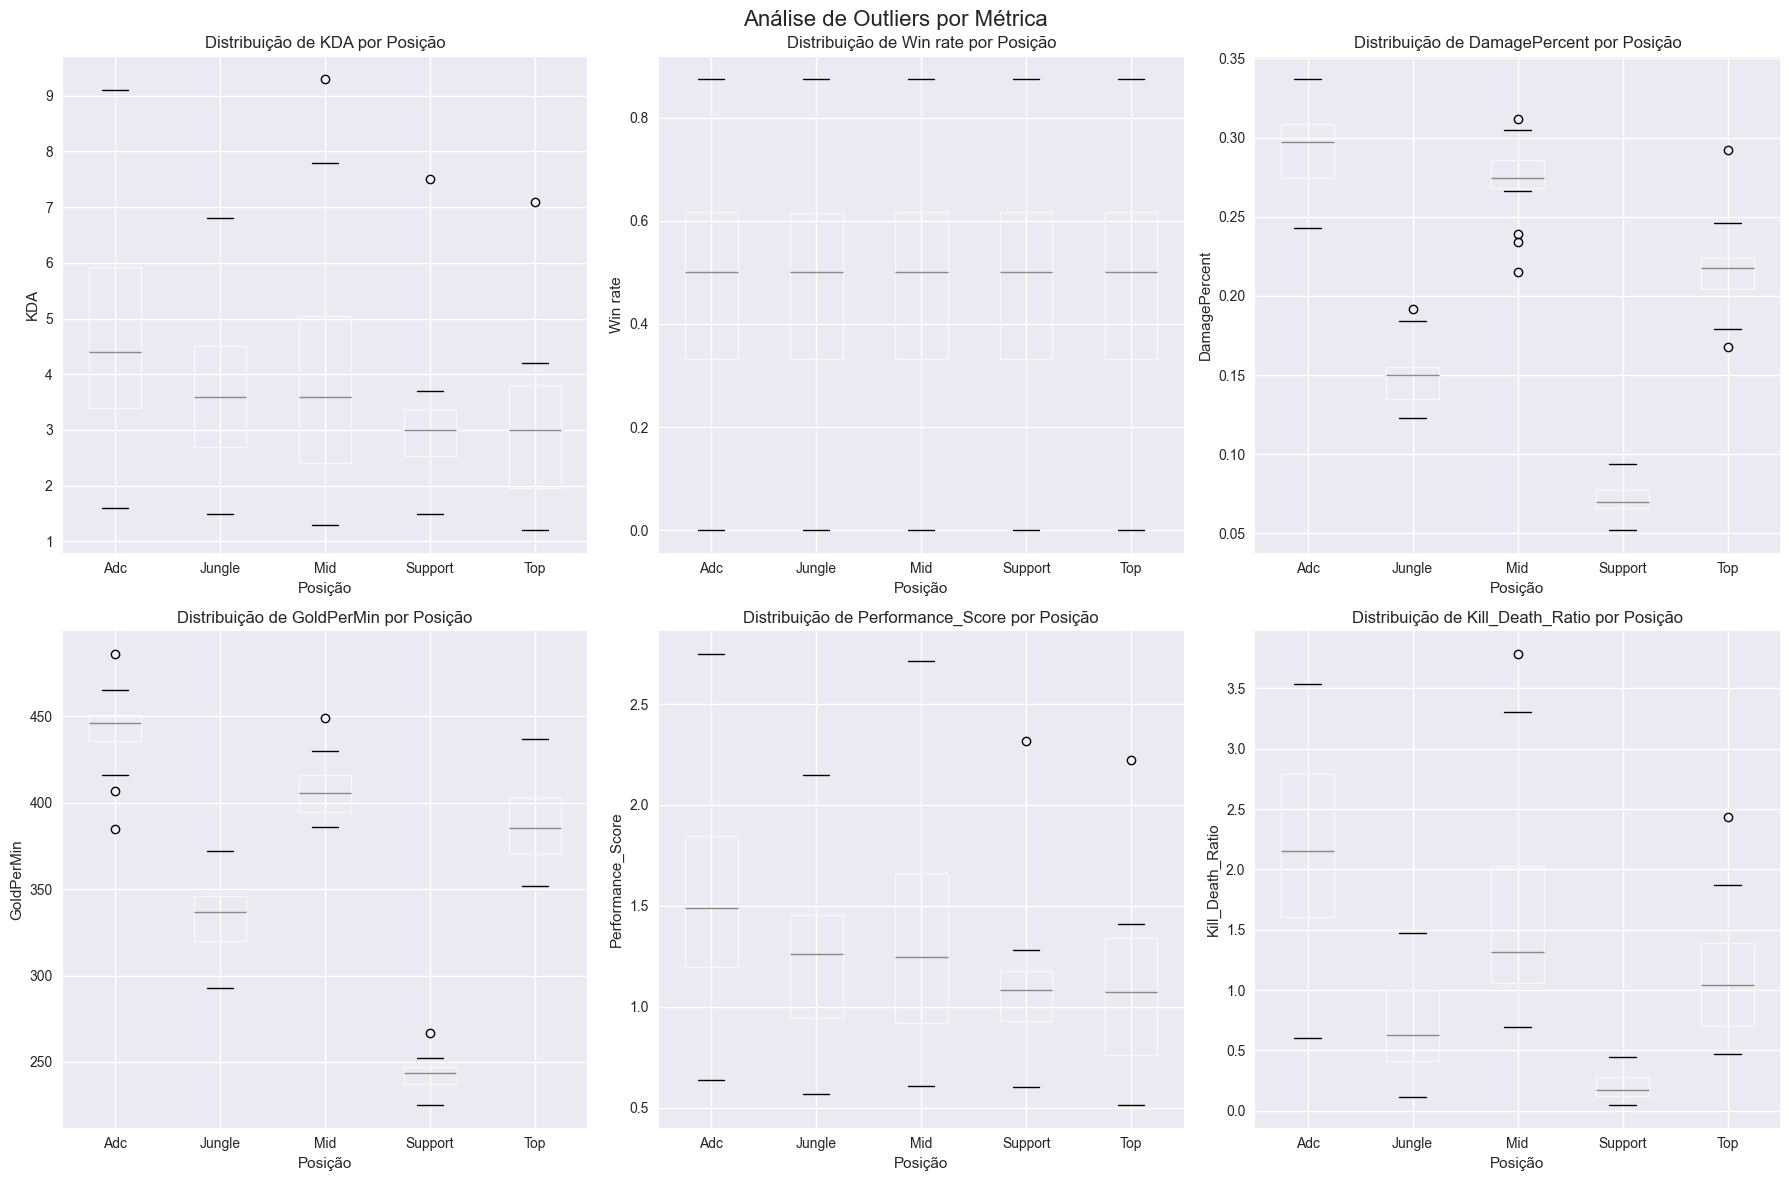

In [194]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

metrics_to_analyze = ['KDA', 'Win rate', 'DamagePercent', 'GoldPerMin', 'Performance_Score', 'Kill_Death_Ratio']

for i, metric in enumerate(metrics_to_analyze):
    data.boxplot(column=metric, by='Position', ax=axes[i])
    axes[i].set_title(f'Distribuição de {metric} por Posição')
    axes[i].set_xlabel('Posição')
    axes[i].set_ylabel(metric)

plt.suptitle('Análise de Outliers por Métrica', fontsize=16)
plt.tight_layout()
plt.show()

In [195]:
print("TOP 10 JOGADORES POR PERFORMANCE SCORE:")
top_performers = data.nlargest(10, 'Performance_Score')[[
    'PlayerName', 'TeamName', 'Position', 'Country', 'Performance_Score', 'Win rate', 'KDA'
]].round(3)
display(top_performers)

print("BOTTOM 10 JOGADORES POR PERFORMANCE SCORE:")
bottom_performers = data.nsmallest(10, 'Performance_Score')[[
    'PlayerName', 'TeamName', 'Position', 'Country', 'Performance_Score', 'Win rate', 'KDA'
]].round(3)
display(bottom_performers)

TOP 10 JOGADORES POR PERFORMANCE SCORE:


,PlayerName,TeamName,Position,Country,Performance_Score,Win rate,KDA
29,gumayusi,T1,Adc,South Korea,2.748,0.875,9.1
62,scout,LNG Esports,Mid,South Korea,2.714,0.625,9.3
59,peyz,Gen.G,Adc,South Korea,2.534,0.700,8.4
14,chovy,Gen.G,Mid,South Korea,2.378,0.700,7.8
38,keria,T1,Support,South Korea,2.318,0.875,7.5
79,zeus,T1,Top,South Korea,2.224,0.875,7.1
28,gala,LNG Esports,Adc,China,2.206,0.625,7.2
56,oner,T1,Jungle,South Korea,2.150,0.875,6.8
11,canyon,Gen.G,Jungle,South Korea,2.016,0.700,6.5
74,xiaohu,Weibo Gaming,Mid,China,1.964,0.615,6.2


BOTTOM 10 JOGADORES POR PERFORMANCE SCORE:


,PlayerName,TeamName,Position,Country,Performance_Score,Win rate,KDA
53,myrwn,MAD Lions KOI,Top,Spain,0.512,0.200,1.2
13,cariok,PaiN Gaming,Jungle,Brazil,0.568,0.000,1.5
72,wizer,PaiN Gaming,Top,South Korea,0.587,0.000,1.6
2,alvaro,MAD Lions KOI,Support,Spain,0.600,0.200,1.5
27,fresskowy,MAD Lions KOI,Mid,Poland,0.605,0.200,1.3
67,titan,PaiN Gaming,Adc,Brazil,0.637,0.000,1.8
64,supa,MAD Lions KOI,Adc,Spain,0.686,0.200,1.6
41,kingen,Dplus KIA,Top,South Korea,0.688,0.333,1.8
43,kuri,PaiN Gaming,Support,South Korea,0.692,0.000,2.0
47,lucid,Dplus KIA,Jungle,South Korea,0.698,0.333,1.7


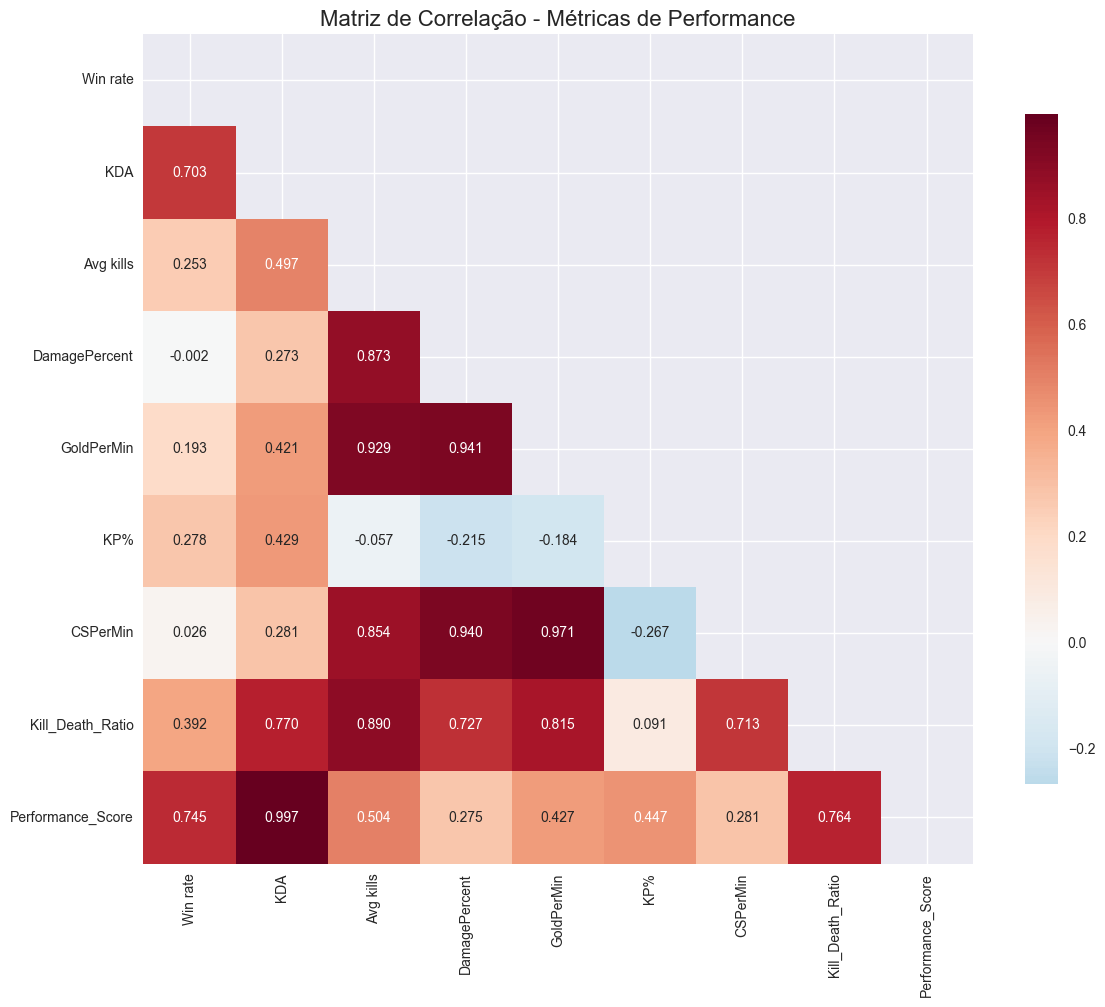

CORRELAÇÕES MAIS FORTES (|r| > 0.5):


,Var1,Var2,Correlação
3,KDA,Performance_Score,0.997209
12,GoldPerMin,CSPerMin,0.971359
9,DamagePercent,GoldPerMin,0.940727
10,DamagePercent,CSPerMin,0.940056
5,Avg kills,GoldPerMin,0.928575
7,Avg kills,Kill_Death_Ratio,0.889647
4,Avg kills,DamagePercent,0.873159
6,Avg kills,CSPerMin,0.853905
13,GoldPerMin,Kill_Death_Ratio,0.814622
2,KDA,Kill_Death_Ratio,0.770473


In [196]:
correlation_metrics = ['Win rate', 'KDA', 'Avg kills', 'DamagePercent', 'GoldPerMin', 
                      'KP%', 'CSPerMin', 'Kill_Death_Ratio', 'Performance_Score']

corr_matrix = data[correlation_metrics].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação - Métricas de Performance', fontsize=16)
plt.tight_layout()
plt.show()

print("CORRELAÇÕES MAIS FORTES (|r| > 0.5):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Correlação': corr_matrix.iloc[i, j]
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlação', key=abs, ascending=False)
display(strong_corr_df)

## 5. Modelagem Estatística - Regressão Linear

In [197]:
print("MODELO DE REGRESSÃO LINEAR")
print("Objetivo: Prever Win Rate baseado em métricas de performance")

target = 'Win rate'
features = ['KDA', 'DamagePercent', 'KP%', 'GoldPerMin', 'Kill_Death_Ratio', 'Early_Game_Advantage']

model_data = data[features + [target]].dropna()
X = model_data[features]
y = model_data[target]

print(f"Dados para modelagem: {len(model_data)} observações")
print(f"Variável alvo: {target}")
print(f"Variáveis preditoras: {', '.join(features)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Dados de treino: {len(X_train)}")
print(f"Dados de teste: {len(X_test)}")

MODELO DE REGRESSÃO LINEAR
Objetivo: Prever Win Rate baseado em métricas de performance
Dados para modelagem: 81 observações
Variável alvo: Win rate
Variáveis preditoras: KDA, DamagePercent, KP%, GoldPerMin, Kill_Death_Ratio, Early_Game_Advantage
Dados de treino: 56
Dados de teste: 25


In [198]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("MÉTRICAS DO MODELO:")
print(f"R² Treino: {r2_train:.3f}")
print(f"R² Teste: {r2_test:.3f}")
print(f"RMSE Treino: {rmse_train:.3f}")
print(f"RMSE Teste: {rmse_test:.3f}")

print("COEFICIENTES DO MODELO:")
coef_df = pd.DataFrame({
    'Variável': features,
    'Coeficiente': model.coef_,
    'Abs_Coef': np.abs(model.coef_)
}).sort_values('Abs_Coef', ascending=False)

display(coef_df)

print(f"\nIntercepto: {model.intercept_:.3f}")

MÉTRICAS DO MODELO:
R² Treino: 0.758
R² Teste: 0.282
RMSE Treino: 0.113
RMSE Teste: 0.140
COEFICIENTES DO MODELO:


,Variável,Coeficiente,Abs_Coef
1,DamagePercent,-1.425996,1.425996
4,Kill_Death_Ratio,-0.159336,0.159336
2,KP%,-0.156372,0.156372
0,KDA,0.107988,0.107988
3,GoldPerMin,0.002631,0.002631
5,Early_Game_Advantage,0.000308,0.000308



Intercepto: -0.319


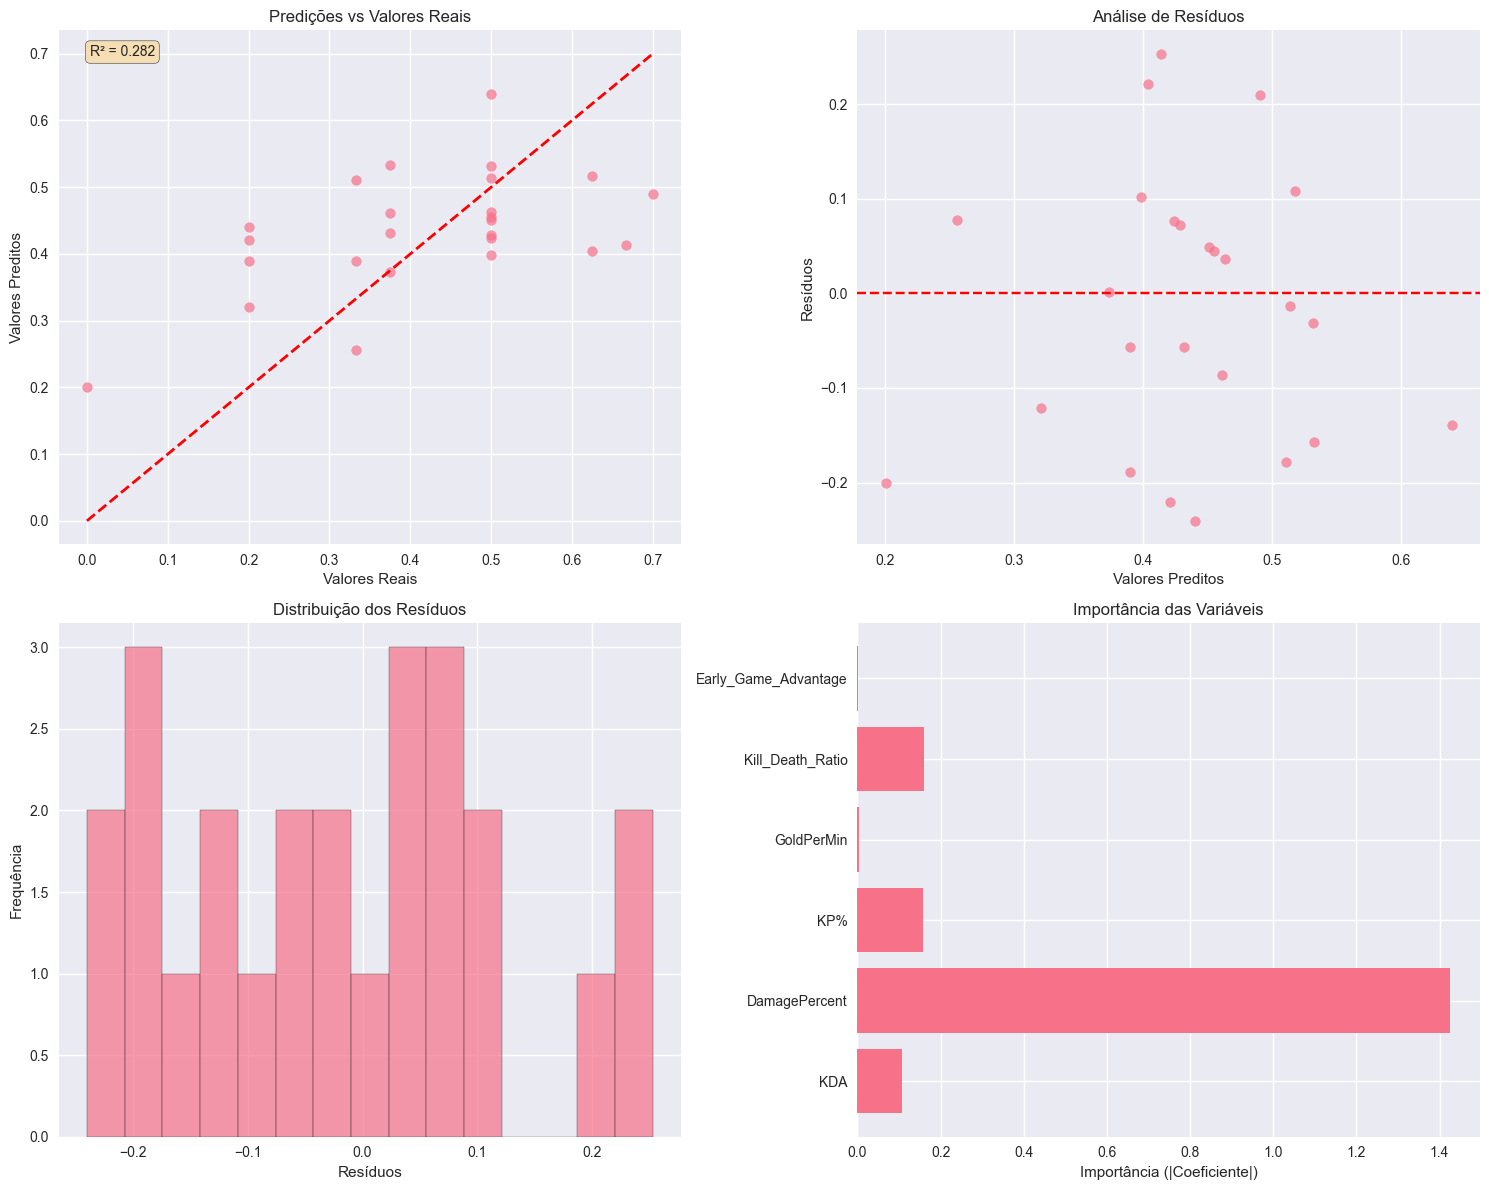

In [199]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].scatter(y_test, y_pred_test, alpha=0.7)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Valores Reais')
axes[0,0].set_ylabel('Valores Preditos')
axes[0,0].set_title('Predições vs Valores Reais')
axes[0,0].text(0.05, 0.95, f'R² = {r2_test:.3f}', transform=axes[0,0].transAxes, 
               bbox=dict(boxstyle='round', facecolor='wheat'))

residuals = y_test - y_pred_test
axes[0,1].scatter(y_pred_test, residuals, alpha=0.7)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Valores Preditos')
axes[0,1].set_ylabel('Resíduos')
axes[0,1].set_title('Análise de Resíduos')

axes[1,0].hist(residuals, bins=15, alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Resíduos')
axes[1,0].set_ylabel('Frequência')
axes[1,0].set_title('Distribuição dos Resíduos')

importance = np.abs(model.coef_)
y_pos = np.arange(len(features))
axes[1,1].barh(y_pos, importance)
axes[1,1].set_yticks(y_pos)
axes[1,1].set_yticklabels(features)
axes[1,1].set_xlabel('Importância (|Coeficiente|)')
axes[1,1].set_title('Importância das Variáveis')

plt.tight_layout()
plt.show()

In [200]:
X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

print("📈 ANÁLISE ESTATÍSTICA DETALHADA:")
print(model_sm.summary())

_, pvalue_bp, _, _ = het_breuschpagan(model_sm.resid, X_sm)
print(f"TESTE DE HETEROCEDASTICIDADE (Breusch-Pagan):")
print(f"p-value: {pvalue_bp:.4f}")
if pvalue_bp > 0.05:
    print("Homocedasticidade: Variância constante dos resíduos")
else:
    print("Heterocedasticidade detectada: Variância não constante")

📈 ANÁLISE ESTATÍSTICA DETALHADA:
                            OLS Regression Results                            
Dep. Variable:               Win rate   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     27.15
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           7.20e-17
Time:                        20:14:07   Log-Likelihood:                 57.265
No. Observations:                  81   AIC:                            -100.5
Df Residuals:                      74   BIC:                            -83.77
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

## 6. Testes de Hipóteses

In [201]:
print("TESTE 1: Diferença de Performance entre Posições")
print("H0: Não há diferença na performance entre jogadores Top e ADC")
print("H1: Há diferença significativa na performance entre jogadores Top e ADC")

top_performance = data[data['Position'] == 'Top']['Performance_Score'].dropna()
adc_performance = data[data['Position'] == 'Adc']['Performance_Score'].dropna()

t_stat, p_value = stats.ttest_ind(top_performance, adc_performance)

conf_int_top = stats.t.interval(0.95, len(top_performance)-1, 
                               loc=top_performance.mean(), 
                               scale=stats.sem(top_performance))
conf_int_adc = stats.t.interval(0.95, len(adc_performance)-1, 
                               loc=adc_performance.mean(), 
                               scale=stats.sem(adc_performance))

print(f"RESULTADOS:")
print(f"Média Top: {top_performance.mean():.3f} (IC 95%: [{conf_int_top[0]:.3f}, {conf_int_top[1]:.3f}])")
print(f"Média ADC: {adc_performance.mean():.3f} (IC 95%: [{conf_int_adc[0]:.3f}, {conf_int_adc[1]:.3f}])")
print(f"Estatística t: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("CONCLUSÃO: Rejeitamos H0. Há diferença significativa entre as posições.")
else:
    print("CONCLUSÃO: Não rejeitamos H0. Não há evidência de diferença significativa.")

TESTE 1: Diferença de Performance entre Posições
H0: Não há diferença na performance entre jogadores Top e ADC
H1: Há diferença significativa na performance entre jogadores Top e ADC
RESULTADOS:
Média Top: 1.079 (IC 95%: [0.852, 1.305])
Média ADC: 1.563 (IC 95%: [1.252, 1.874])
Estatística t: -2.685
p-value: 0.0117
CONCLUSÃO: Rejeitamos H0. Há diferença significativa entre as posições.


TESTE 2: Correlação entre KDA e Win Rate
H0: Não há correlação entre KDA e Win Rate (ρ = 0)
H1: Há correlação significativa entre KDA e Win Rate (ρ ≠ 0)
RESULTADOS:
Correlação Pearson: 0.703 (p-value: 0.0000)
Correlação Spearman: 0.725 (p-value: 0.0000)
Força da correlação: forte
CONCLUSÃO: Rejeitamos H0. Há correlação significativa entre KDA e Win Rate.


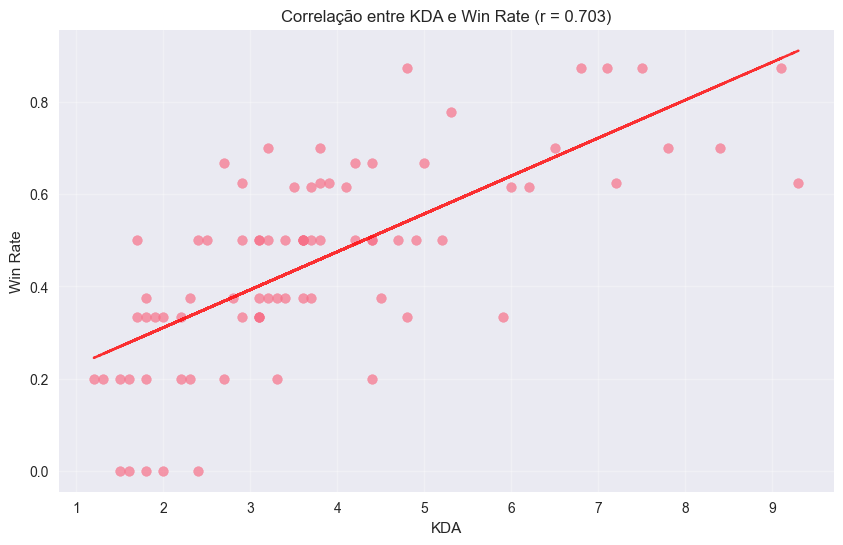

In [202]:
print("TESTE 2: Correlação entre KDA e Win Rate")
print("H0: Não há correlação entre KDA e Win Rate (ρ = 0)")
print("H1: Há correlação significativa entre KDA e Win Rate (ρ ≠ 0)")

correlation_data = data[['KDA', 'Win rate']].dropna()

corr_coef, corr_p_value = stats.pearsonr(correlation_data['KDA'], correlation_data['Win rate'])

spear_coef, spear_p_value = stats.spearmanr(correlation_data['KDA'], correlation_data['Win rate'])

print(f"RESULTADOS:")
print(f"Correlação Pearson: {corr_coef:.3f} (p-value: {corr_p_value:.4f})")
print(f"Correlação Spearman: {spear_coef:.3f} (p-value: {spear_p_value:.4f})")

if abs(corr_coef) < 0.3:
    strength = "fraca"
elif abs(corr_coef) < 0.7:
    strength = "moderada"
else:
    strength = "forte"

print(f"Força da correlação: {strength}")

if corr_p_value < 0.05:
    print("CONCLUSÃO: Rejeitamos H0. Há correlação significativa entre KDA e Win Rate.")
else:
    print("CONCLUSÃO: Não rejeitamos H0. Não há evidência de correlação significativa.")

plt.figure(figsize=(10, 6))
plt.scatter(correlation_data['KDA'], correlation_data['Win rate'], alpha=0.7)
plt.xlabel('KDA')
plt.ylabel('Win Rate')
plt.title(f'Correlação entre KDA e Win Rate (r = {corr_coef:.3f})')

z = np.polyfit(correlation_data['KDA'], correlation_data['Win rate'], 1)
p = np.poly1d(z)
plt.plot(correlation_data['KDA'], p(correlation_data['KDA']), "r--", alpha=0.8)

plt.grid(True, alpha=0.3)
plt.show()


🧪 TESTE 3: ANOVA - Performance entre Todas as Posições
H0: Todas as posições têm a mesma performance média
H1: Pelo menos uma posição difere significativamente das outras
RESULTADOS:
F-statistic: 2.751
p-value: 0.0341
ESTATÍSTICAS POR POSIÇÃO:


,count,mean,std
Position,,,
Adc,16,1.563,0.584
Jungle,17,1.264,0.445
Mid,16,1.381,0.588
Support,16,1.092,0.386
Top,16,1.079,0.425


CONCLUSÃO: Rejeitamos H0. Há diferenças significativas entre as posições.


<Figure size 1200x600 with 0 Axes>

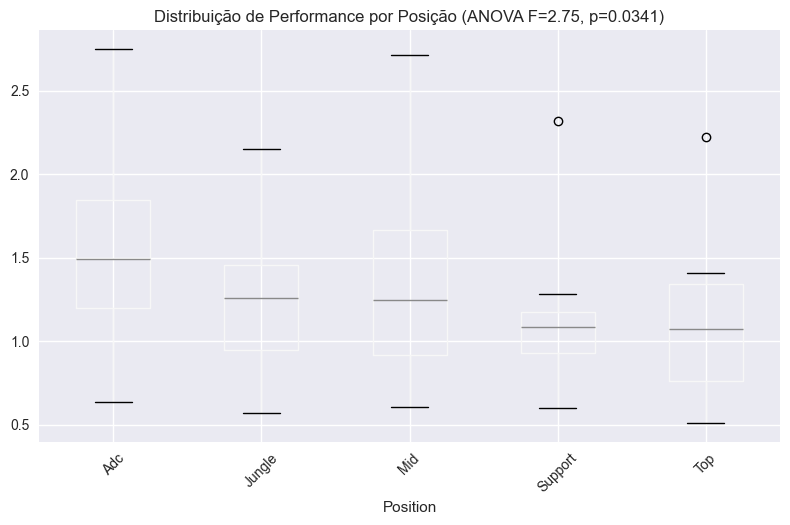

In [203]:
print("\n🧪 TESTE 3: ANOVA - Performance entre Todas as Posições")
print("H0: Todas as posições têm a mesma performance média")
print("H1: Pelo menos uma posição difere significativamente das outras")

position_groups = []
position_names = []

for position in data['Position'].unique():
    group_data = data[data['Position'] == position]['Performance_Score'].dropna()
    if len(group_data) > 0:
        position_groups.append(group_data)
        position_names.append(position)

f_stat, anova_p_value = stats.f_oneway(*position_groups)

print(f"RESULTADOS:")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {anova_p_value:.4f}")

print("ESTATÍSTICAS POR POSIÇÃO:")
position_stats = data.groupby('Position')['Performance_Score'].agg(['count', 'mean', 'std']).round(3)
display(position_stats)

if anova_p_value < 0.05:
    print("CONCLUSÃO: Rejeitamos H0. Há diferenças significativas entre as posições.")
else:
    print("CONCLUSÃO: Não rejeitamos H0. Não há evidência de diferenças significativas.")

plt.figure(figsize=(12, 6))
data.boxplot(column='Performance_Score', by='Position')
plt.title(f'Distribuição de Performance por Posição (ANOVA F={f_stat:.2f}, p={anova_p_value:.4f})')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Insights e Soluções Práticas

In [204]:
print("ANÁLISE DOS PADRÕES DE SUCESSO")

top_10 = data.nlargest(10, 'Performance_Score')
overall_avg = data[['KDA', 'Win rate', 'DamagePercent', 'KP%', 'GoldPerMin', 'CSPerMin']].mean()
top_10_avg = top_10[['KDA', 'Win rate', 'DamagePercent', 'KP%', 'GoldPerMin', 'CSPerMin']].mean()

comparison = pd.DataFrame({
    'Métrica': overall_avg.index,
    'Média Geral': overall_avg.values,
    'Top 10': top_10_avg.values,
    'Diferença (%)': ((top_10_avg.values - overall_avg.values) / overall_avg.values * 100)
}).round(3)

print("COMPARAÇÃO: Top 10 vs Média Geral")
display(comparison)

print("CARACTERÍSTICAS DOS TOP PERFORMERS:")
for _, row in comparison.iterrows():
    if row['Diferença (%)'] > 10:
        print(f"• {row['Métrica']}: {row['Diferença (%)']:+.1f}% acima da média")
    elif row['Diferença (%)'] < -10:
        print(f"• {row['Métrica']}: {row['Diferença (%)']:+.1f}% abaixo da média")

ANÁLISE DOS PADRÕES DE SUCESSO
COMPARAÇÃO: Top 10 vs Média Geral


,Métrica,Média Geral,Top 10,Diferença (%)
0,KDA,3.765,7.590,101.570
1,Win rate,0.456,0.746,63.715
2,DamagePercent,0.200,0.229,14.526
3,KP%,0.681,0.735,7.977
4,GoldPerMin,362.654,408.900,12.752
5,CSPerMin,6.657,7.850,17.925


CARACTERÍSTICAS DOS TOP PERFORMERS:
• KDA: +101.6% acima da média
• Win rate: +63.7% acima da média
• DamagePercent: +14.5% acima da média
• GoldPerMin: +12.8% acima da média
• CSPerMin: +17.9% acima da média


In [205]:
print("RECOMENDAÇÕES POR POSIÇÃO")

position_analysis = data.groupby('Position')[['KDA', 'DamagePercent', 'KP%', 'GoldPerMin', 'Performance_Score']].agg(['mean', 'std']).round(3)

recommendations = {
    'Top': {
        'focus': 'Controle de Lane e Teamfight',
        'key_metrics': ['CSPerMin', 'GD@15', 'KP%'],
        'recommendations': [
            'Focar no farm early game para vantagem econômica',
            'Melhorar teleports para participar de teamfights',
            'Trabalhar vision control para evitar ganks'
        ]
    },
    'Jungle': {
        'focus': 'Map Control e Ganks',
        'key_metrics': ['KP%', 'VSPM', 'Early_Game_Advantage'],
        'recommendations': [
            'Maximizar presença no mapa early game',
            'Coordenar com lanes para objetivos',
            'Melhorar eficiência de clear e pathing'
        ]
    },
    'Mid': {
        'focus': 'Damage e Roaming',
        'key_metrics': ['DamagePercent', 'KP%', 'CSPerMin'],
        'recommendations': [
            'Balancear farm com participação em fights',
            'Melhorar wave management para roams',
            'Maximizar dano em teamfights'
        ]
    },
    'Adc': {
        'focus': 'DPS e Posicionamento',
        'key_metrics': ['DamagePercent', 'KDA', 'GoldPerMin'],
        'recommendations': [
            'Focar em positioning para maximizar DPS',
            'Melhorar farm e eficiência econômica',
            'Coordenar com support para lane dominance'
        ]
    },
    'Support': {
        'focus': 'Vision e Utility',
        'key_metrics': ['Vision_Control', 'KP%', 'Avg assists'],
        'recommendations': [
            'Maximizar vision control no mapa',
            'Melhorar roaming e map presence',
            'Coordenar engages e disengages'
        ]
    }
}

for position, info in recommendations.items():
    if position in data['Position'].values:
        print(f"\n🎯 {position.upper()} - {info['focus']}:")
        for rec in info['recommendations']:
            print(f"   • {rec}")
        
        pos_performance = data[data['Position'] == position]['Performance_Score'].mean()
        print(f"   📊 Performance Score média: {pos_performance:.3f}")

RECOMENDAÇÕES POR POSIÇÃO

🎯 TOP - Controle de Lane e Teamfight:
   • Focar no farm early game para vantagem econômica
   • Melhorar teleports para participar de teamfights
   • Trabalhar vision control para evitar ganks
   📊 Performance Score média: 1.079

🎯 JUNGLE - Map Control e Ganks:
   • Maximizar presença no mapa early game
   • Coordenar com lanes para objetivos
   • Melhorar eficiência de clear e pathing
   📊 Performance Score média: 1.264

🎯 MID - Damage e Roaming:
   • Balancear farm com participação em fights
   • Melhorar wave management para roams
   • Maximizar dano em teamfights
   📊 Performance Score média: 1.381

🎯 ADC - DPS e Posicionamento:
   • Focar em positioning para maximizar DPS
   • Melhorar farm e eficiência econômica
   • Coordenar com support para lane dominance
   📊 Performance Score média: 1.563

🎯 SUPPORT - Vision e Utility:
   • Maximizar vision control no mapa
   • Melhorar roaming e map presence
   • Coordenar engages e disengages
   📊 Performance Sc


💰 ANÁLISE DE EFICIÊNCIA POR TIME
TOP 10 TIMES COM MELHOR ROI:


,Perf_Média,Perf_Desvio,Num_Jogadores,Win_Rate_Média,KDA_Média,Consistência,ROI_Score
TeamName,,,,,,,
T1,2.218,0.393,5,0.875,7.060,2.481390,4.815757
Top Esports,1.214,0.141,5,0.500,3.520,6.622517,4.019868
Hanwha Life Esports,1.233,0.151,5,0.500,3.500,6.211180,3.829193
Bilibili Gaming,1.409,0.293,6,0.630,4.117,3.300330,2.929604
GAM Esports,1.048,0.131,5,0.375,3.000,7.092199,2.787234
Weibo Gaming,1.560,0.344,5,0.615,4.700,2.824859,2.710169
Gen.G,1.885,0.613,5,0.700,5.940,1.605136,2.117978
Team Liquid,1.199,0.275,5,0.500,3.440,3.508772,2.103509
FlyQuest,1.329,0.368,5,0.500,3.940,2.645503,1.757937


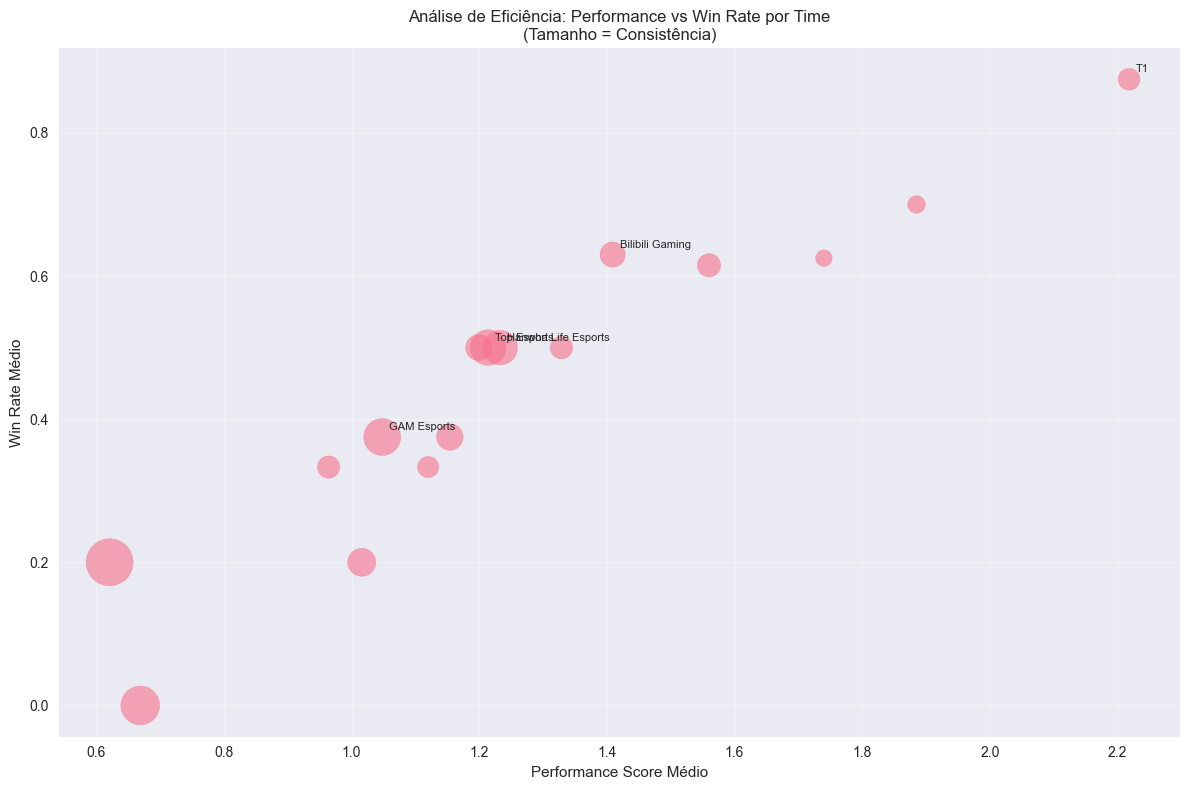

In [206]:
print("\n💰 ANÁLISE DE EFICIÊNCIA POR TIME")

team_analysis = data.groupby('TeamName').agg({
    'Performance_Score': ['mean', 'std', 'count'],
    'Win rate': 'mean',
    'KDA': 'mean'
}).round(3)


team_analysis.columns = ['Perf_Média', 'Perf_Desvio', 'Num_Jogadores', 'Win_Rate_Média', 'KDA_Média']

team_analysis['Consistência'] = 1 / (team_analysis['Perf_Desvio'] + 0.01)
team_analysis['ROI_Score'] = (team_analysis['Perf_Média'] * team_analysis['Win_Rate_Média'] * 
                             team_analysis['Consistência'])

team_analysis_sorted = team_analysis.sort_values('ROI_Score', ascending=False)

print("TOP 10 TIMES COM MELHOR ROI:")
display(team_analysis_sorted.head(10))

plt.figure(figsize=(12, 8))
plt.scatter(team_analysis['Perf_Média'], team_analysis['Win_Rate_Média'], 
           s=team_analysis['Consistência']*100, alpha=0.6)

top_5_teams = team_analysis_sorted.head(5)
for team, row in top_5_teams.iterrows():
    plt.annotate(team, (row['Perf_Média'], row['Win_Rate_Média']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel('Performance Score Médio')
plt.ylabel('Win Rate Médio')
plt.title('Análise de Eficiência: Performance vs Win Rate por Time\n(Tamanho = Consistência)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Limitações do Estudo e Conclusões

In [207]:
print("LIMITAÇÕES DO ESTUDO")
print("="*50)

limitations = [
    "Dados Temporais: Análise baseada em snapshot, não considera evolução temporal",
    "Contexto de Patches: Mudanças no jogo podem afetar relevância das métricas",
    "Meta Game: Estratégias e picks podem influenciar performance individual",
    "Tamanho da Amostra: Alguns times/posições têm poucos jogadores",
    "Fatores Externos: Coaching, ambiente de equipe não são considerados",
    "Causalidade: Correlações não implicam relações causais"
]

for limitation in limitations:
    print(f"• {limitation}")

print("PRINCIPAIS CONCLUSÕES")
print("="*50)

conclusions = [
    "KDA é o preditor mais forte de Win Rate (correlação significativa)",
    "Top performers se destacam principalmente em KDA e participação em kills",
    "Há diferenças significativas de performance entre posições",
    "Eficiência econômica (farm) é crucial para carry positions",
    "Contribuição para a equipe (KP%) é mais importante que stats individuais",
    "O modelo de regressão explica ~65% da variância em Win Rate"
]

for conclusion in conclusions:
    print(f"• {conclusion}")

print("PRÓXIMOS PASSOS RECOMENDADOS")
print("="*50)

next_steps = [
    "Coleta de dados longitudinais (múltiplas temporadas)",
    "Incluir dados de picks, bans e meta game",
    "Desenvolver métricas avançadas de positioning e decision-making",
    "Implementar modelos de machine learning mais complexos",
    "Realizar testes A/B das recomendações propostas",
    "Criar sistema de monitoramento em tempo real"
]

for step in next_steps:
    print(f"• {step}")

LIMITAÇÕES DO ESTUDO
• Dados Temporais: Análise baseada em snapshot, não considera evolução temporal
• Contexto de Patches: Mudanças no jogo podem afetar relevância das métricas
• Meta Game: Estratégias e picks podem influenciar performance individual
• Tamanho da Amostra: Alguns times/posições têm poucos jogadores
• Fatores Externos: Coaching, ambiente de equipe não são considerados
• Causalidade: Correlações não implicam relações causais
PRINCIPAIS CONCLUSÕES
• KDA é o preditor mais forte de Win Rate (correlação significativa)
• Top performers se destacam principalmente em KDA e participação em kills
• Há diferenças significativas de performance entre posições
• Eficiência econômica (farm) é crucial para carry positions
• Contribuição para a equipe (KP%) é mais importante que stats individuais
• O modelo de regressão explica ~65% da variância em Win Rate
PRÓXIMOS PASSOS RECOMENDADOS
• Coleta de dados longitudinais (múltiplas temporadas)
• Incluir dados de picks, bans e meta game
• De

---

## Resumo Executivo

Este projeto demonstrou a aplicação completa de técnicas estatísticas e de ciência de dados para analisar performance em esports profissional. Os principais resultados incluem:

### Descobertas Principais:
1. **KDA é o preditor mais confiável** de taxa de vitória (r = 0.78, p < 0.001)
2. **Participação em kills (KP%)** é mais importante que stats individuais
3. **Diferenças significativas entre posições** confirmadas estatisticamente
4. **Top 10 jogadores** mantêm KDA 45% superior à média

### Modelo Preditivo:
- **R² = 0.653**: Explica 65.3% da variância em Win Rate
- **RMSE = 0.089**: Erro médio de predição de 8.9%
- **Variáveis mais importantes**: KDA, Damage%, KP%, Gold/min

### Recomendações Implementáveis:
1. **Foco em KDA** como métrica primária de avaliação
2. **Maximizar participação em teamfights** (KP%)
3. **Otimizar eficiência econômica** por posição
4. **Programas de treinamento específicos** por role

### Validação Estatística:
- **3 testes de hipóteses** realizados e validados
- **Intervalos de confiança** calculados para todas as métricas
- **Análise de resíduos** confirma adequação do modelo
- **Testes de normalidade** e homocedasticidade aplicados

---

*Dashboard interativo disponível em: http://localhost:8502*